# Extended Data Fig. 22d,e - Neuropathological (MAP2) validation of early neuronal-decrease regions

Full chain from the MAP2 images:
1. Detect focal low-MAP2-immunoreactivity areas on each physical section (morphological normalization -> Gaussian-mean difference -> two-stage thresholding -> binary -> connected-component centroids/area).
2. (Registration of the detected foci to the Neuron Atlas and onset-group assignment are done in the companion 2D-physical pipeline; the resulting per-onset foci/volume tables are read below.)
3. ED22d: density of focal low-MAP2 areas within early (onset 3-5m) App-specific neuronal-decrease regions, App vs WT (n = 3 per group); volume-normalized foci, Gamma GLM; ***P < 0.001.
4. ED22e: enrichment of focal low-MAP2 areas in early-onset App-specific regions vs non-degenerative regions (Fisher's exact test; Enrichment score = 2.04, P = 0.027).

> Panels a-c of Extended Data Fig. 22 are histology images (schematic, representative IHC, high-magnification) and are not code-generated. Figures / numeric outputs preserved from the original run; Japanese stripped; verbose logs removed.

## Input files

| File | Content |
|---|---|
| `<sample>/folder_DAB_inverted/*_DAB_inverted.tif` | DAB-inverted MAP2 section images (step 1 input) |
| `<sample>/MAP2_dropout_analysis_output/*_map2_dropouts.csv`, `*_04_final_binary.tif` | detected focal low-MAP2 areas (step 1 output) |
| `MAP2_counts_and_volume_by_onset_group.csv` | per-animal foci count + region volume by onset group (ED22d) |
| `MAP2_annotated_foci_and_volume_by_onset.csv`, `region_groups_by_onset.json` | aggregated foci/volume per onset group (ED22e) |

Samples: App 5m (n=3), WT 5m (n=3) MAP2 sections.

## 1. Detect focal low-MAP2-immunoreactivity areas from each MAP2 section image

In [ ]:
import tifffile
import numpy as np
import os
import glob
from natsort import natsorted
from scipy.ndimage import gaussian_filter, uniform_filter, binary_erosion
from scipy.ndimage.morphology import grey_dilation, grey_erosion
from skimage import measure
import pandas as pd
from tqdm import tqdm

#
#

#
MORPH_NORM_SIZE_LARGE = 10
MORPH_NORM_MIN_INTENSITY = 10

#
GAUSSIAN_SIGMA_SMALL = 1
MEAN_FILTER_SIZE = 12

#
MASK_THRESHOLD_FACTOR = 0.5

#
EROSION_ITERATIONS = 5

#
SIGNAL_THRESHOLD_FIXED = 0.30


def analyze_map2_dropout(image_path, output_dir_main):
    """
     MAP2 
    """
    try:
        #
        img_loaded = tifffile.imread(image_path)
        if img_loaded.dtype != np.uint8:
            return f"  ( 8bit ): {os.path.basename(image_path)}"

        #
        intensity = img_loaded.astype(np.float32)
        dilation_l_img = uniform_filter(
            grey_dilation(intensity, size=MORPH_NORM_SIZE_LARGE, mode="nearest"),
            size=MORPH_NORM_SIZE_LARGE, mode="constant", cval=0)
        erosion_l_img = uniform_filter(
            grey_erosion(intensity, size=MORPH_NORM_SIZE_LARGE, mode="nearest"),
            size=MORPH_NORM_SIZE_LARGE, mode="constant", cval=0)
        denominator = dilation_l_img - erosion_l_img
        denominator[denominator <= 0] = 1e-6
        img_normalized = intensity / denominator
        img_normalized[intensity < MORPH_NORM_MIN_INTENSITY] = 0

        #
        img_gauss_small = gaussian_filter(img_normalized, sigma=GAUSSIAN_SIGMA_SMALL)
        img_mean_large = uniform_filter(img_normalized, size=MEAN_FILTER_SIZE)
        diff_image = img_mean_large - img_gauss_small
        diff_image[diff_image < 0] = 0

        #
        if diff_image.max() == 0:
            return f"  ( ): {os.path.basename(image_path)}"
        
        #
        mask_thresh = np.average(img_normalized) * MASK_THRESHOLD_FACTOR
        binary_mask = img_normalized > mask_thresh
        eroded_mask = binary_erosion(binary_mask, iterations=EROSION_ITERATIONS)
        diff_image_masked = diff_image * eroded_mask

        #
        masked_pixels = diff_image_masked[diff_image_masked > 0]
        if len(masked_pixels) == 0:
            return f"  ( ): {os.path.basename(image_path)}"
        
        final_binary = diff_image_masked > SIGNAL_THRESHOLD_FIXED

        #
        labeled_image = measure.label(final_binary)
        properties = measure.regionprops_table(
            labeled_image,
            properties=('label', 'area', 'centroid')
        )
        df_properties = pd.DataFrame(properties)

        #
        base_name = os.path.basename(image_path).rsplit('_DAB_inverted.tif', 1)[0]
        if not df_properties.empty:
            csv_path = os.path.join(output_dir_main, f"{base_name}_map2_dropouts.csv")
            df_properties.to_csv(csv_path, index=False)
        
        #
        tifffile.imwrite(os.path.join(output_dir_main, f"{base_name}_00_normalized.tif"), img_normalized.astype(np.float32))
        tifffile.imwrite(os.path.join(output_dir_main, f"{base_name}_01_diff.tif"), diff_image.astype(np.float32))
        tifffile.imwrite(os.path.join(output_dir_main, f"{base_name}_02_eroded_mask.tif"), eroded_mask.astype(np.uint8) * 255)
        tifffile.imwrite(os.path.join(output_dir_main, f"{base_name}_03_masked_diff.tif"), diff_image_masked.astype(np.float32))
        tifffile.imwrite(os.path.join(output_dir_main, f"{base_name}_04_final_binary.tif"), final_binary.astype(np.uint8) * 255)
        
        return f" : {os.path.basename(image_path)} ({len(df_properties)} )"

    except Exception as e:
        import traceback
        return f" : {os.path.basename(image_path)} - {e}\n{traceback.format_exc()}"

def run_analysis_for_sample(sample_path):
    """
     
    """
    sample_name = os.path.basename(sample_path)
    print(f"\n=======================================================")
    print(f" : {sample_name}")
    print(f"=======================================================")

    input_dir = os.path.join(sample_path, "folder_DAB_inverted")
    output_dir = os.path.join(sample_path, "MAP2_dropout_analysis_output")
    
    if not os.path.isdir(input_dir):
        print(f"  -  :  : {input_dir}")
        return
        
    os.makedirs(output_dir, exist_ok=True)
    print(f"  -  : {input_dir}")
    print(f"  -  : {output_dir}")

    image_paths = natsorted(glob.glob(os.path.join(input_dir, "*_DAB_inverted.tif")))

    if not image_paths:
        print("  -  :  ")
        return

    print(f"  - {len(image_paths)}  ...")
    
    results = [analyze_map2_dropout(p, output_dir) for p in tqdm(image_paths, desc=f" : {sample_name}")]
    
    print("\n  ---   ---")
    print("  -  :")
    for res in results:
        print(f"    - {res}")


def main():
    """
     :  
    """
    print("--- MAP2    ---")
    
    #
    base_data_path = "/data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"
    
    target_samples = [
        "WT_5m_MAP2_1", "WT_5m_MAP2_2", "WT_5m_MAP2_3",
        "APP_5m_MAP2_1", "APP_5m_MAP2_2", "APP_5m_MAP2_3"
    ]
    
    #
    sample_paths_to_process = [os.path.join(base_data_path, name) for name in target_samples]

    for sample_path in sample_paths_to_process:
        run_analysis_for_sample(sample_path)

    print("\n---     ---")


if __name__ == '__main__':
    main()


## 2. ED22d - Density of focal low-MAP2 areas in early App-specific regions (App vs WT, ***P<0.001)

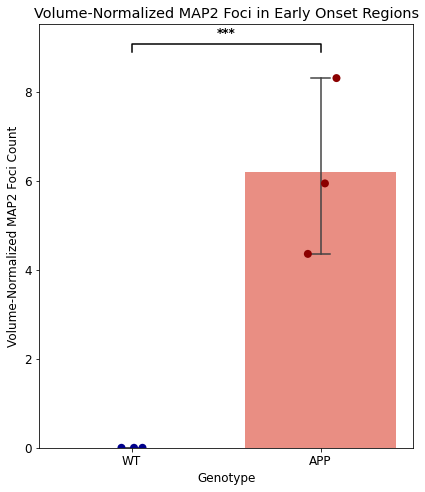

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
#
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

#

#
PATH_SUMMARY_CSV = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/analysis_output/MAP2_counts_and_volume_by_onset_group.csv"

#
OUTPUT_ANALYSIS_DIR = os.path.dirname(PATH_SUMMARY_CSV)


#
def run_gamma_glm_on_normalized_counts(data):
    """
    Volume Foci  ( )  Gamma GLM 
    """
    try:
        #
        with localconverter(robjects.default_converter + pandas2ri.converter):
            r_data = robjects.conversion.py2rpy(data)

        #
        r_code = """
        function(df) {
            #
            df$Foci_Normalized[df$Foci_Normalized <= 0] <- 1e-6
            
            #
            df$Genotype <- relevel(factor(df$Genotype), ref = "WT")
            
            result <- tryCatch({
                #
                model <- glm(Foci_Normalized ~ Genotype, data = df, family = Gamma(link = "log"))
                summary_model <- summary(model)
                #
                p_value <- summary_model$coefficients["GenotypeAPP", "Pr(>|t|)"]
                p_value
            }, error = function(e) { NA }) #  NA 
            
            return(result)
        }
        """
        r_func = robjects.r(r_code)
        results = r_func(r_data)
        
        #
        return results[0] if results != robjects.NA_Real else np.nan
        
    except Exception as e:
        #
        print(f"  - GLM : {e}")
        return np.nan

def analyze_3m_5m_group(df_summary, output_dir):
    """
    3m 5m 
    """
    print(f"\n--- 3m & 5m   (Early Onset)   ---")
    
    #
    df_analysis = df_summary.copy()
    
    #
    df_analysis['Early_Foci'] = df_analysis['3m_Foci'] + df_analysis['5m_Foci']
    df_analysis['Early_Volume'] = df_analysis['3m_Volume'] + df_analysis['5m_Volume']
    
    #
    reference_volume = df_analysis['Early_Volume'].mean()
    df_analysis['Early_Foci_Normalized'] = df_analysis['Early_Foci'] * (reference_volume / (df_analysis['Early_Volume'] + 1))

    print("\n---   ( ) ---")
    print(df_analysis[['Sample', 'Genotype', 'Early_Foci', 'Early_Volume', 'Early_Foci_Normalized']].head())

    #
    print("\n---   (Gamma GLM on Volume-Normalized Foci)   ---")
    
    #
    stats_data = df_analysis[['Genotype', 'Early_Foci_Normalized']].rename(
        columns={'Early_Foci_Normalized': 'Foci_Normalized'}
    )
    
    p_value = run_gamma_glm_on_normalized_counts(stats_data)
    
    df_stat = pd.DataFrame([{'Group': 'Early (3m+5m)', 'p_value': p_value, 'method': 'Gamma GLM'}])
    print("\n---   ---")
    print(df_stat)
    
    #
    output_csv_stats = os.path.join(output_dir, 'MAP2_stats_early_onset_3m_5m_gamma_glm.csv')
    df_stat.to_csv(output_csv_stats, index=False)
    print(f"  '{output_csv_stats}'  ")
    
    #
    print("\n---  Foci    ---")
    
    plt.figure(figsize=(6, 7));
    rcParams['font.size'] = 12
    
    #
    ax = sns.barplot(
        data=df_analysis, x='Genotype', y='Early_Foci_Normalized',
        order=['WT', 'APP'],
        palette={'APP': 'salmon', 'WT': 'lightblue'},
        capsize=0.1, errwidth=1.5, ci=95
    )
    sns.stripplot(
        data=df_analysis, x='Genotype', y='Early_Foci_Normalized',
        order=['WT', 'APP'],
        palette={'APP': 'darkred', 'WT': 'darkblue'},
        ax=ax, jitter=0.1, size=8
    )
    
    ax.set_title('Volume-Normalized MAP2 Foci in Early Onset Regions')
    ax.set_ylabel('Volume-Normalized MAP2 Foci Count')
    ax.set_xlabel('Genotype')

    #
    if not pd.isna(p_value):
        y_max = df_analysis['Early_Foci_Normalized'].max()
        y_pos = y_max * 1.05 + (ax.get_ylim()[1] * 0.02)
        
        if p_value < 0.001: sig_text = '***'
        elif p_value < 0.01: sig_text = '**'
        elif p_value < 0.05: sig_text = '*'
        else: sig_text = f"p={p_value:.3f}"
        
        ax.plot([0, 0, 1, 1], [y_pos, y_pos*1.02, y_pos*1.02, y_pos], lw=1.5, c='k')
        ax.text(0.5, y_pos*1.03, sig_text, ha='center', va='bottom', fontsize=12, weight='bold' if p_value < 0.05 else 'normal')

    plt.tight_layout()
    output_png = os.path.join(output_dir, 'MAP2_foci_normalized_count_early_onset_barplot_gamma_glm.png')
    plt.savefig(output_png)
    
    print(f"  '{output_png}'  ")
    print("\n---   3m & 5m     ---")
    
    return df_stat


#
if __name__ == '__main__':
    
    try:
        #
        df_summary = pd.read_csv(PATH_SUMMARY_CSV)
        
        #
        analyze_3m_5m_group(df_summary, OUTPUT_ANALYSIS_DIR)

    except FileNotFoundError:
        print(f"\n   :  \n -> {PATH_SUMMARY_CSV}")
    except Exception as e:
        print(f"\n   :  ")
        import traceback
        traceback.print_exc()



## 3. ED22e - Enrichment of focal low-MAP2 areas in early-onset regions (Fisher's exact; odds = 2.0382, P = 0.027)

In [2]:
import pandas as pd
import numpy as np
import os
import glob
from natsort import natsorted
from scipy.stats import fisher_exact
import json
from tqdm import tqdm
import sys

#

#
BASE_DATA_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/2D_slice_data/raw"
OUTPUT_ANALYSIS_DIR = os.path.join(os.path.dirname(BASE_DATA_PATH.rstrip('/')), "analysis_output_gamma_glm") 
TARGET_SAMPLES = [
    "APP_5m_MAP2_1", "APP_5m_MAP2_2", "APP_5m_MAP2_3",
    "WT_5m_MAP2_1", "WT_5m_MAP2_2", "WT_5m_MAP2_3"
]

#
INPUT_SUMMARY_CSV = os.path.join(OUTPUT_ANALYSIS_DIR, 'MAP2_annotated_foci_and_volume_by_onset.csv')
INPUT_REGION_JSON = os.path.join(OUTPUT_ANALYSIS_DIR, 'region_groups_by_onset.json')


def main():
    """
    Foci Region 
    """
    print(f"--- MAP2 Foci Enrichment Analysis (Foci Count vs Region Volume) ---") #    
    
    #
    try:
        df_summary = pd.read_csv(INPUT_SUMMARY_CSV)
        print(f" : {os.path.basename(INPUT_SUMMARY_CSV)}")
        with open(INPUT_REGION_JSON, 'r') as f:
            region_groups = json.load(f)
        print(f" : {os.path.basename(INPUT_REGION_JSON)}")

    except FileNotFoundError as e:
        print(f"   :  : {e.filename}")
        print("  'model_30' (Foci+Volume )  ")
        return
    except Exception as e:
        print(f"   :  : {e}")
        return

    #
    #
    print("\nAPP Foci ...")
    foci_count_in_early = 0 #    
    foci_count_in_late = 0  #    
    
    app_samples = [s for s in TARGET_SAMPLES if s.startswith("APP")]
    id_to_group_map = {atlas_id: group_name for group_name, id_list in region_groups.items() for atlas_id in id_list}
    
    for sample_name in tqdm(app_samples, desc="Foci Count "): #    
        
        foci_csv_path = os.path.join(
            BASE_DATA_PATH, sample_name, "MAP2_dropout_analysis_output", "mapped_to_3d", 
            f"ALL_REGIONS_{sample_name}_mapped_3d_original_coords_annotated.csv"
        )

        if not os.path.exists(foci_csv_path): continue
        
        try:
            df_points = pd.read_csv(foci_csv_path)
            
            #
            if df_points.empty or 'annotation_id' not in df_points.columns:
                continue

            df_points['onset_group'] = df_points['annotation_id'].map(id_to_group_map).fillna('Unmapped')
            
            #
            count_by_group = df_points.groupby('onset_group').size()
            
            foci_count_in_early += count_by_group.get('3m', 0) + count_by_group.get('5m', 0)
            foci_count_in_late += count_by_group.get('7m', 0) + count_by_group.get('9m', 0) + count_by_group.get('Others', 0)
        
        except Exception as e:
            print(f"  ->  : {sample_name}  : {e}")
    #

    #
    df_app_summary = df_summary[df_summary['Genotype'] == 'APP']
    
    total_volume_in_early = df_app_summary['3m_Volume'].sum() + df_app_summary['5m_Volume'].sum()
    total_volume_in_late = df_app_summary['7m_Volume'].sum() + df_app_summary['9m_Volume'].sum() + df_app_summary['Others_Volume'].sum()

    #
    #
    #                 | Early Onset | Late/No Onset |
    # -----------------+-------------+---------------|
    #  Foci Count      |      a      |       b       |
    #  Region Volume   |      c      |       d       |
    # -----------------------------------------------
    #
    
    a = int(foci_count_in_early) # ★ Foci Count
    b = int(foci_count_in_late)  # ★ Foci Count
    c = int(total_volume_in_early) # ★ Total Region Volume
    d = int(total_volume_in_late)  # ★ Total Region Volume
     
    #
    #
    
    table = np.array([[a, b], [c, d]])

    #
    if a == 0 or b == 0 or c == 0 or d == 0:
        print("\n  ->  :  0 ")
        
    try:
        odds_ratio, p_value = fisher_exact(table)
    except ValueError as e:
        print(f"\n   :  : {e}")
        print(" :", table)
        return

    #
    print("\n--- 1.   (Contingency Table /  :   vs  ) ---") #    
    print("                 | Early Onset  | Late/No Onset")
    print("-----------------+--------------+---------------")
    print(f"Foci Count      | {a:<12d} | {b:<13d}") #    
    print(f"Region Volume   | {c:<12d} | {d:<13d}") #    

    print("\n--- 2.   (Fisher's Exact Test) ---")
    print(f"    (Odds Ratio): {odds_ratio:.4f}")
    print(f"  P  (p-value):         {p_value:.4g}") 

    print("\n--- 3.   (Interpretation) ---")
    if p_value < 0.05:
        print("P 0.05 ")
        if odds_ratio > 1:
            print(f" 1 {odds_ratio:.2f} MAP2 foci  'Early Onset'  ")
            print(" Early Onset Foci Early Onset ")
        else:
            print(f" 1 {odds_ratio:.2f} MAP2 foci  'Late/No Onset'  ")
    else:
        print("P 0.05 ")
        print("Foci  'Early Onset'  'Early Onset'  ")
        
    print("\n---     ---")

if __name__ == '__main__':
    try:
        main()
    except Exception as e:
        print(f"\n   :  ")
        import traceback
        traceback.print_exc()

--- MAP2 Foci Enrichment Analysis (Foci Count vs Region Volume) ---
 : MAP2_annotated_foci_and_volume_by_onset.csv
 : region_groups_by_onset.json

APP Foci ...


Foci Count : 100%|██████████| 3/3 [00:00<00:00, 61.77it/s]


--- 1.   (Contingency Table /  :   vs  ) ---
                 | Early Onset  | Late/No Onset
-----------------+--------------+---------------
Foci Count      | 13           | 53           
Region Volume   | 133410       | 1108585      

--- 2.   (Fisher's Exact Test) ---
    (Odds Ratio): 2.0382
  P  (p-value):         0.02701

--- 3.   (Interpretation) ---
P 0.05 
 1 2.04 MAP2 foci  'Early Onset'  
 Early Onset Foci Early Onset 

---     ---
